### Импортируем библиотеки

In [1]:
%%capture
!pip install torch torchvision torchaudio clip-openai faiss-gpu pandas numpy Pillow tqdm

In [2]:
# Стандартная библиотека
import os
import random

# Сторонние библиотеки
import numpy as np
import pandas as pd
import PIL.Image
import faiss
import clip
from tqdm.notebook import tqdm

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

### Загрузим данные

In [3]:
kaggle = True
dir = '/data/'
if kaggle:
    dir = '/kaggle/input/homework-06b/dataset/'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

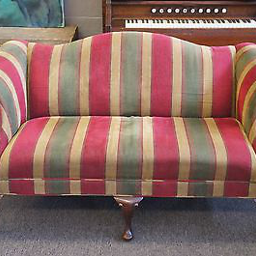

In [4]:
rnd = random.randint(0, 9604)
img_rnd = PIL.Image.open(dir + f'{rnd}.png')

img_rnd

#### Функция для создания Dataset

In [5]:
class ImageDatasetForCLIP(Dataset):
    def __init__(self, data_dir, preprocess):
        """
        Args:
            data_dir (str): Путь к директории с изображениями ('0000.png'...'9604.png').
            preprocess (callable): Функция предобработки изображений от CLIP.
        """
        self.data_dir = data_dir
        self.preprocess = preprocess
        self.filenames = [f"{i:04d}.png" for i in range(9605)]

    def __len__(self):
        return 9605

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        base_filename = self.filenames[idx]
        img_path = os.path.join(self.data_dir, base_filename)

        image = PIL.Image.open(img_path).convert("RGB")
        image_preprocessed = self.preprocess(image)

        return image_preprocessed, base_filename

#### Функция для извлечения эмбеддингов изображений с помощью модели CLIP

In [6]:
def extract_embeddings(dataloader, model, device):
    """
    Извлекает эмбеддинги изображений с помощью модели CLIP.

    Args:
        dataloader (DataLoader): DataLoader с предобработанными изображениями и именами файлов.
        model (CLIP): Загруженная модель CLIP.
        device (torch.device): Устройство ('cuda' или 'cpu'), на котором выполняется модель.

    Returns:
        tuple: Кортеж из двух элементов:
            - np.ndarray: Массив NumPy с эмбеддингами изображений (формат: [N, D],
                          где N - количество изображений, D - размерность эмбеддинга).
            - list: Список имен файлов, соответствующий порядку эмбеддингов.
    """
    all_embeddings = []
    all_filenames = []
    
    model.eval()
    
    with torch.no_grad():
        for images_batch, filenames_batch in tqdm(dataloader, desc="Извлечение эмбеддингов"):
            
            valid_indices = [i for i, img in enumerate(images_batch) if img is not None]

            valid_images = torch.stack([images_batch[i] for i in valid_indices])
            valid_filenames = [filenames_batch[i] for i in valid_indices]

            images_batch_device = valid_images.to(device)
            
            embeddings_batch = model.encode_image(images_batch_device)
            
            embeddings_batch_normalized = embeddings_batch / embeddings_batch.norm(dim=-1, keepdim=True)
            embeddings_batch_np = embeddings_batch_normalized.cpu().numpy()
            
            all_embeddings.append(embeddings_batch_np)
            all_filenames.extend(valid_filenames)

    final_embeddings = np.concatenate(all_embeddings, axis=0)
    
    return final_embeddings, all_filenames

#### Функция поиска ближайших соседей

In [7]:
def find_nearest_neighbors_faiss(embeddings, DEVICE, k_neighbors=7):
    """
    Ищет k ближайших соседей для каждого вектора в embeddings с помощью Faiss.
    
    Args:
        embeddings (np.ndarray): Массив эмбеддингов (N, D).
        k_neighbors (int): Количество ближайших соседей для поиска.

    Returns:
        tuple: Кортеж (distances, indices), где:
               - distances (np.ndarray): Массив расстояний до соседей (N, k).
               - indices (np.ndarray): Массив индексов соседей (N, k).
    """
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension) 
    
    # Если используется GPU:
    if DEVICE == "cuda":
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)

    print(f"Добавляем {len(embeddings)} эмбеддингов в индекс Faiss...")
    index.add(embeddings.astype(np.float32))

    distances, indices = index.search(embeddings.astype(np.float32), k_neighbors)
    
    return distances, indices

### Теперь это всё реализуем и сохраним в `submission.csv`

In [8]:
MODEL_NAME = "ViT-B/32"
batch_size = 128

# 1. Загрузка модели CLIP
model, preprocess = clip.load(MODEL_NAME, device=device)

# 2. Создание Dataset и DataLoader
image_dataset = ImageDatasetForCLIP(data_dir=dir, preprocess=preprocess)
image_dataloader = DataLoader(image_dataset, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count()//2 or 1) 

# 3. Извлечение эмбеддингов
embeddings, filenames = extract_embeddings(image_dataloader, model, device)

# 4. Поиск ближайших соседей
distances, indices = find_nearest_neighbors_faiss(embeddings, device)

Извлечение эмбеддингов:   0%|          | 0/76 [00:00<?, ?it/s]

Добавляем 9605 эмбеддингов в индекс Faiss...


In [9]:
# 5. Создание файла submission.csv
results = {'filename': [], 'ranking': []}
    
print("Формирование файла submission...")
for i, query_filename in enumerate(tqdm(filenames, desc="Обработка результатов")):
    indices_for_query = indices[i]
    
    top_neighbors_indices = indices_for_query[1 : 7] 
    
    neighbor_filenames = [filenames[idx] for idx in top_neighbors_indices]
    
    results['filename'].append(query_filename)
    results['ranking'].append(" ".join(neighbor_filenames))

submission_df = pd.DataFrame(results)
submission_df.to_csv('submission.csv', index=False, sep=',')
print("Файл submission.csv успешно создан.")

Формирование файла submission...


Обработка результатов:   0%|          | 0/9605 [00:00<?, ?it/s]

Файл submission.csv успешно создан.
